# Ce40-based q-range descriptor results: `q0.3-11`

Fixed range: `QMIN = 0.3`, `QMAX = 11`. This notebook was generated from `B-descriptors-Ce40_qrange.ipynb`; outputs belong only to this range.


This notebook aims at training the ML algorithms using structure-related decriptors

**Dataset B**: Calculated PDFs of Ce40-based clusters

**Classes**: Nuclearity classes (1–9)

In [1]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
from numpy import trapz
import sys
from pathlib import Path

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Locate the project root whether this template or a generated copy is running
PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / 'config.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.py from the current working directory")
sys.path.insert(0, str(PROJECT_ROOT))

import config
from config import get_path, setup_workdir, qrange_paths, qrange_tag, QRANGE_PAIRS

# --- qrange-study: choose the (qmin, qmax) pair ----------------------------
PAIR_INDEX = None  # published baseline; QMIN/QMAX below are fixed
QMIN, QMAX = (0.3, 11.0)
TAG = qrange_tag(QMIN, QMAX)
_qrange = qrange_paths(QMIN, QMAX)
_qrange['ce_calculated_pdfs'] = get_path('ce_calculated_pdfs')
print(f"qrange-study: descriptors for (qmin={QMIN}, qmax={QMAX})  [{TAG}]")

qrange-study: descriptors for (qmin=0.3, qmax=11.0)  [q0.3-11]


Plot the distribution of cluster nuclearities in the dataset B

Using all 10000 PDFs: {'1': 2188, '2': 2614, '3': 2100, '4': 1433, '5': 857, '6': 472, '7': 215, '8': 95, '9': 26}


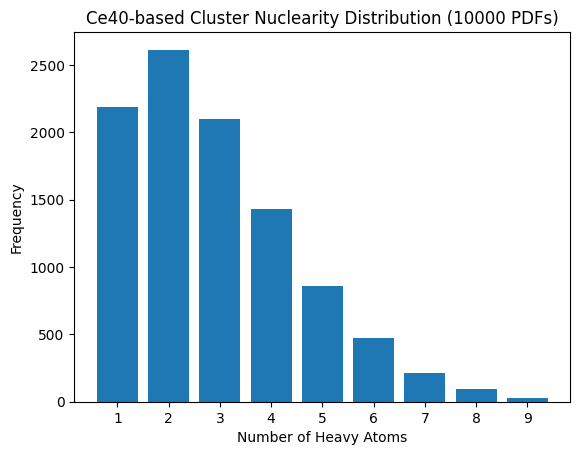

In [2]:
# Use the same complete PDF catalogue used by the models below
pdf_dir = _qrange['ce_calculated_pdfs']
files_for_distribution = sorted(pdf_dir.glob('*.dat'), key=lambda path: path.name)
numbers = [int(path.name[0]) for path in files_for_distribution]

def count_occurrences(values):
    count_dict = {str(i): 0 for i in range(1, 10)}
    for value in values:
        count_dict[str(value)] += 1
    return count_dict

def plot_bar_chart(count_dict):
    nuclearities = list(count_dict.keys())
    counts = list(count_dict.values())

    plt.bar(nuclearities, counts)
    plt.xlabel('Number of Heavy Atoms')
    plt.ylabel('Frequency')
    plt.title(f'Ce40-based Cluster Nuclearity Distribution ({len(numbers)} PDFs)')
    plt.show()

count_dict = count_occurrences(numbers)
print(f"Using all {len(numbers)} PDFs: {count_dict}")
plot_bar_chart(count_dict)

Feature Extraction from PDF Files
- Peak areas and ratios
- Peak positions and heights
- Shell integrals (wider r-range compared to peak area descriptors)
- PDF moments descriptors

PDF files directory: /Volumes/Extreme SSD/WORK/PDF/PDF-NN paper/PDF-NN/pdf-nn-data/ce_clusters/calculated_pdfs
Found 10000 PDF files to process


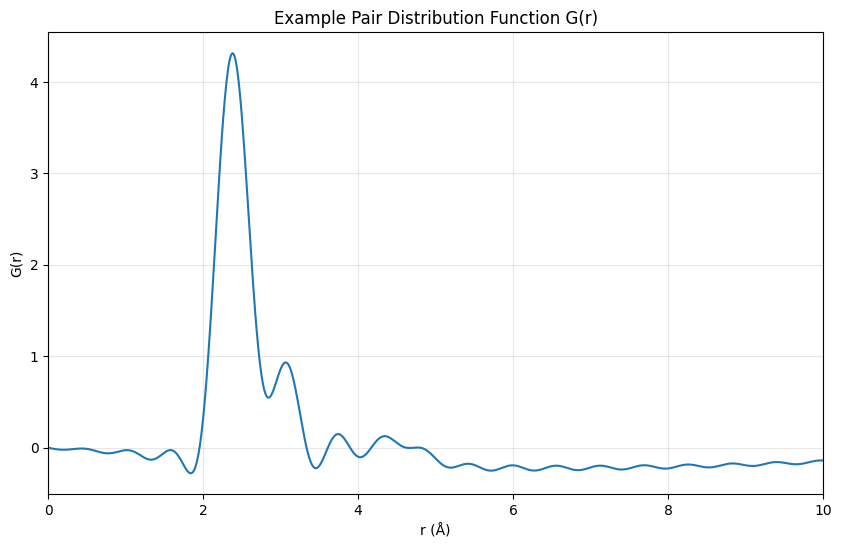

In [3]:
# Select the namespaced PDF input for this q range
pdf_dir = _qrange['ce_calculated_pdfs']
print(f"PDF files directory: {pdf_dir}")

# Stable ordering keeps the same structures in each train/test split across q ranges
files_pdf = sorted(pdf_dir.glob('*.dat'), key=lambda path: path.name)
print(f"Found {len(files_pdf)} PDF files to process")

# Plot example PDF
if len(files_pdf) > 0:
    example_file = files_pdf[0]
    data = pd.read_csv(example_file, skiprows=1, sep=r'\s+', index_col=False)
    data.columns = ['r', 'g']

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(data.r, data.g)
    ax.set_xlim(0, 10)
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('G(r)')
    ax.set_title('Example Pair Distribution Function G(r)')
    ax.grid(True, alpha=0.3)
    plt.show()


In [4]:
print(f"Extracting features from {len(files_pdf)} PDF files...")

def extract_pdf_features(df):
    """Extract comprehensive PDF features for classification"""
    features = {}
    
    # Define peak regions
    peak1_mask = (df['r'] >= 2.0) & (df['r'] <= 3.0)
    peak2_mask = (df['r'] >= 3.5) & (df['r'] <= 4.2) 
    peak3_mask = (df['r'] >= 6.0) & (df['r'] <= 7.0)
    
    peak1 = df.loc[peak1_mask]
    peak2 = df.loc[peak2_mask]
    peak3 = df.loc[peak3_mask]
    
    # Peak areas (integrals of G(r))
    area1 = trapz(peak1.g, peak1.r) if len(peak1) > 0 else 0
    area2 = trapz(peak2.g, peak2.r) if len(peak2) > 0 else 0
    area3 = trapz(peak3.g, peak3.r) if len(peak3) > 0 else 0
    
    features['area1'] = area1
    features['area2'] = area2  
    features['area3'] = area3
    
    # Peak intensity ratios
    features['ratio_21'] = area2/area1 if area1 > 0 else 0
    features['ratio_23'] = area2/area3 if area3 > 0 else 0
    features['ratio_31'] = area3/area1 if area1 > 0 else 0
    
    # Peak positions (r-values at maximum intensity)
    features['peak1_pos'] = peak1.loc[peak1.g.idxmax(), 'r'] if len(peak1) > 0 and peak1.g.max() > 0 else 2.5
    features['peak2_pos'] = peak2.loc[peak2.g.idxmax(), 'r'] if len(peak2) > 0 and peak2.g.max() > 0 else 3.85
    features['peak3_pos'] = peak3.loc[peak3.g.idxmax(), 'r'] if len(peak3) > 0 and peak3.g.max() > 0 else 6.5
    
    # Peak heights (maximum intensities)
    features['peak1_height'] = peak1.g.max() if len(peak1) > 0 else 0
    features['peak2_height'] = peak2.g.max() if len(peak2) > 0 else 0
    features['peak3_height'] = peak3.g.max() if len(peak3) > 0 else 0
    
    # Peak height ratios
    features['height_21'] = features['peak2_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    features['height_31'] = features['peak3_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    
    # Coordination shell integrals (broader regions)
    shell1_mask = (df['r'] >= 1.5) & (df['r'] <= 3.5)
    shell2_mask = (df['r'] >= 3.0) & (df['r'] <= 5.0)
    shell3_mask = (df['r'] >= 5.5) & (df['r'] <= 7.5)
    
    features['shell1'] = trapz(df.loc[shell1_mask, 'g'], df.loc[shell1_mask, 'r']) if shell1_mask.any() else 0
    features['shell2'] = trapz(df.loc[shell2_mask, 'g'], df.loc[shell2_mask, 'r']) if shell2_mask.any() else 0
    features['shell3'] = trapz(df.loc[shell3_mask, 'g'], df.loc[shell3_mask, 'r']) if shell3_mask.any() else 0
    
    # PDF moments and shape descriptors
    r_vals = df['r'].values
    g_vals = df['g'].values
    
    # For PDF, handle negative values by using positive part only
    g_pos = np.maximum(g_vals, 0)
    
    # First moment (weighted average r-position of positive peaks)
    if np.sum(g_pos) > 0:
        features['moment1'] = np.sum(r_vals * g_pos) / np.sum(g_pos)
        features['moment2'] = np.sum((r_vals - features['moment1'])**2 * g_pos) / np.sum(g_pos)  # Variance
    else:
        features['moment1'] = 0
        features['moment2'] = 0
    
    # Total PDF integral (0-10 Å)
    total_mask = (df['r'] >= 0) & (df['r'] <= 10)
    features['total_integral'] = trapz(df.loc[total_mask, 'g'], df.loc[total_mask, 'r']) if total_mask.any() else 0
    
    return features

feature_names = [
    'nuclearity', 'area1', 'area2', 'area3', 'ratio_21', 'ratio_23', 'ratio_31',
    'peak1_pos', 'peak2_pos', 'peak3_pos', 'peak1_height', 'peak2_height', 'peak3_height',
    'height_21', 'height_31', 'shell1', 'shell2', 'shell3',
    'moment1', 'moment2', 'total_integral',
]

all_features = []
failed_files = []
for i, file_path in enumerate(files_pdf):
    try:
        data = pd.read_csv(file_path, skiprows=1, sep=r'\s+', index_col=False)
        data.columns = ['r', 'g']
        features = extract_pdf_features(data)
        nuclearity = int(file_path.name[0])
        all_features.append([nuclearity] + [features[name] for name in feature_names[1:]])
    except Exception as error:
        failed_files.append((file_path.name, str(error)))

    if i == 0 or (i + 1) % 1000 == 0:
        print(f"Processed {i + 1} files...")

if failed_files:
    preview = '\n'.join(f"  {name}: {error}" for name, error in failed_files[:10])
    raise RuntimeError(f"Feature extraction failed for {len(failed_files)} file(s):\n{preview}")

features_data = pd.DataFrame(all_features, columns=feature_names)
print(f"Feature extraction complete: {len(features_data)} samples, {len(feature_names) - 1} features")

Extracting features from 10000 PDF files...
Processed 1 files...


Processed 1000 files...


Processed 2000 files...


Processed 3000 files...


Processed 4000 files...


...

Processed 6000 files...


Processed 7000 files...


Processed 8000 files...


Processed 9000 files...


Processed 10000 files...
Feature extraction complete: 10000 samples, 20 features


Loaded 10000 samples with 20 features
Nuclearity distribution:
nuclearity
1    2188
2    2614
3    2100
4    1433
5     857
6     472
7     215
8      95
9      26
Name: count, dtype: int64


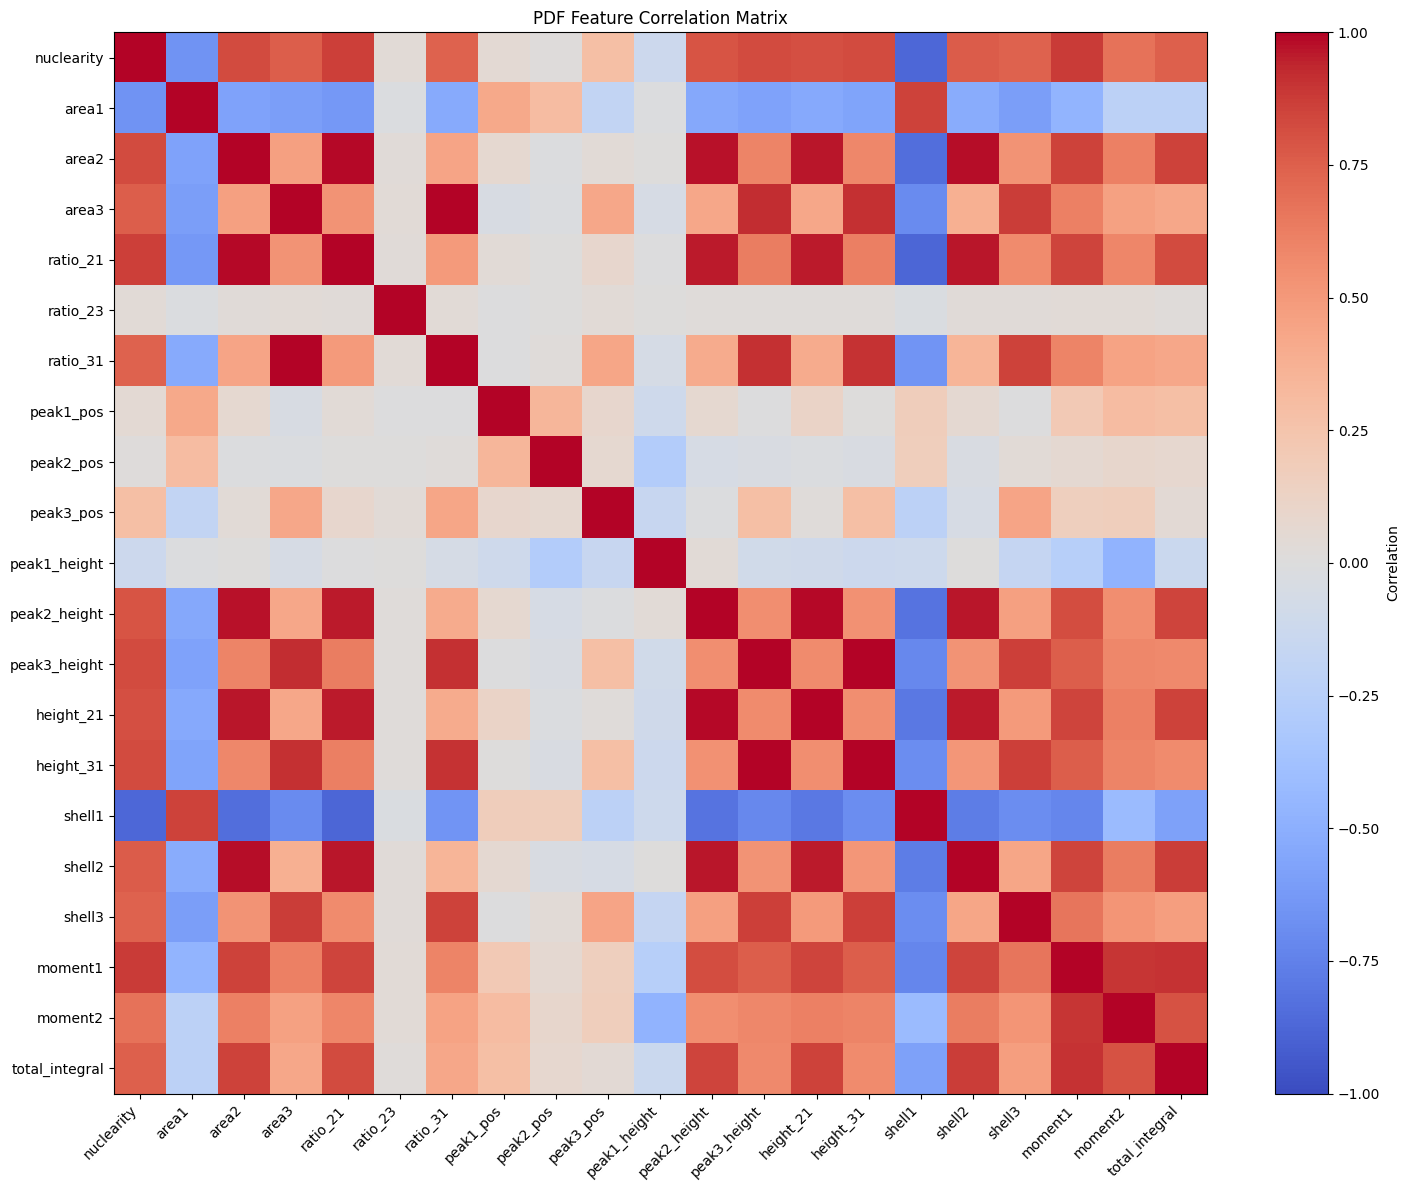

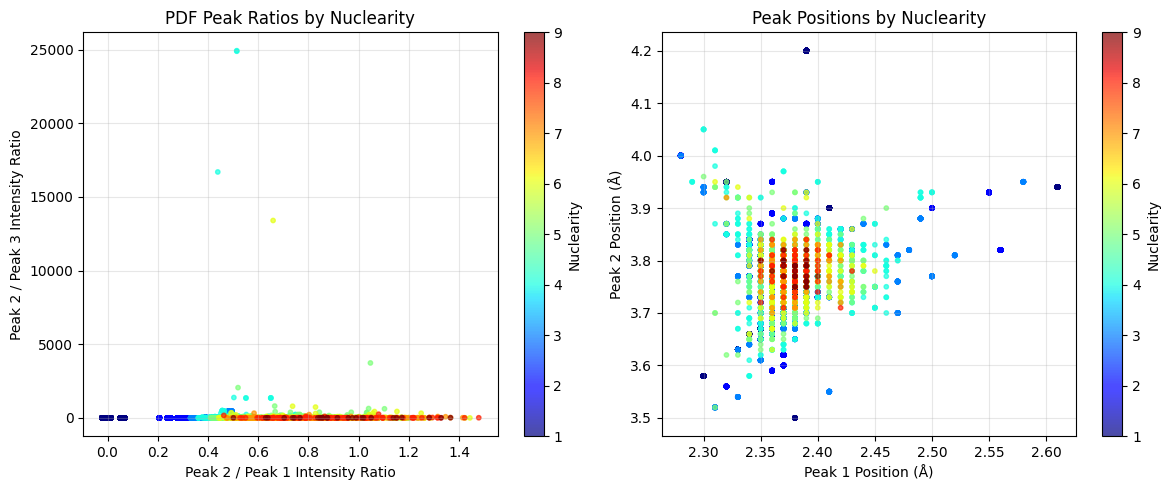

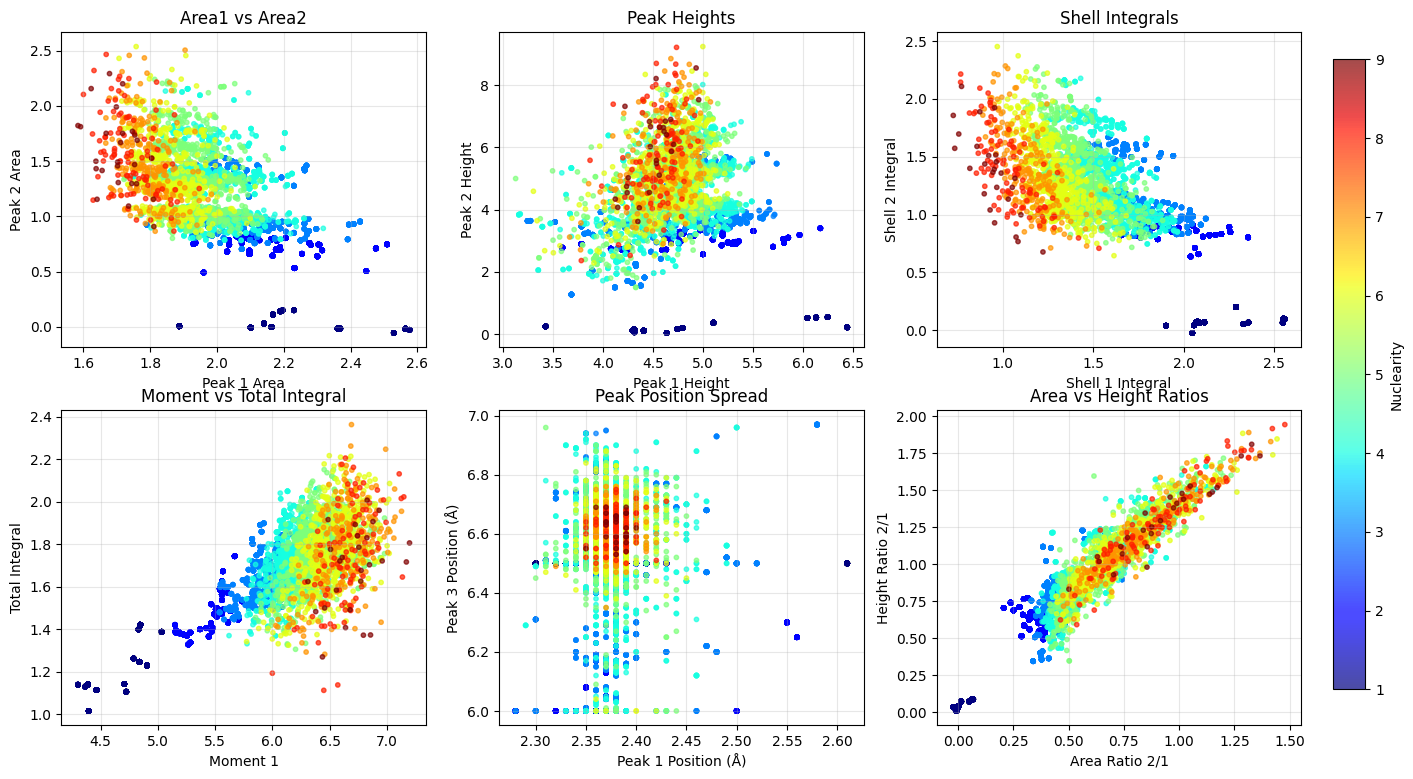


Feature statistics:
       nuclearity      area1      area2      area3   ratio_21   ratio_23  \
count   10000.000  10000.000  10000.000  10000.000  10000.000  10000.000   
mean        2.906      2.087      0.808     -0.129      0.402     16.003   
std         1.647      0.182      0.512      0.163      0.271    416.948   
min         1.000      1.584     -0.056     -0.392     -0.022      0.000   
25%         2.000      1.956      0.639     -0.243      0.278      0.000   
50%         3.000      2.079      0.820     -0.200      0.393      0.000   
75%         4.000      2.178      1.057     -0.030      0.556      0.000   
max         9.000      2.576      2.537      0.660      1.479  24922.954   

        ratio_31  peak1_pos  peak2_pos  peak3_pos  ...  peak2_height  \
count  10000.000  10000.000  10000.000  10000.000  ...     10000.000   
mean      -0.058      2.375      3.767      6.435  ...         3.124   
std        0.080      0.046      0.117      0.227  ...         1.872   
min   

In [5]:
# Visualize the in-memory PDF features
print(f"Loaded {len(features_data)} samples with {len(feature_names)-1} features")
print(f"Nuclearity distribution:")
print(features_data['nuclearity'].value_counts().sort_index())

# Visualize feature correlations
plt.figure(figsize=(15, 12))
correlation_matrix = features_data.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(feature_names)), feature_names)
plt.title('PDF Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Create enhanced scatter plot with original ratios
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(features_data['ratio_21'], features_data['ratio_23'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 2 / Peak 1 Intensity Ratio')
plt.ylabel('Peak 2 / Peak 3 Intensity Ratio')
plt.title('PDF Peak Ratios by Nuclearity')
plt.colorbar(scatter1, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(features_data['peak1_pos'], features_data['peak2_pos'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 1 Position (Å)')
plt.ylabel('Peak 2 Position (Å)')
plt.title('Peak Positions by Nuclearity')
plt.colorbar(scatter2, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional scatter plots for clustering insight
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
scatter_kwargs = dict(c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)

axes[0, 0].scatter(features_data['area1'], features_data['area2'], **scatter_kwargs)
axes[0, 0].set_xlabel('Peak 1 Area')
axes[0, 0].set_ylabel('Peak 2 Area')
axes[0, 0].set_title('Area1 vs Area2')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(features_data['peak1_height'], features_data['peak2_height'], **scatter_kwargs)
axes[0, 1].set_xlabel('Peak 1 Height')
axes[0, 1].set_ylabel('Peak 2 Height')
axes[0, 1].set_title('Peak Heights')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(features_data['shell1'], features_data['shell2'], **scatter_kwargs)
axes[0, 2].set_xlabel('Shell 1 Integral')
axes[0, 2].set_ylabel('Shell 2 Integral')
axes[0, 2].set_title('Shell Integrals')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(features_data['moment1'], features_data['total_integral'], **scatter_kwargs)
axes[1, 0].set_xlabel('Moment 1')
axes[1, 0].set_ylabel('Total Integral')
axes[1, 0].set_title('Moment vs Total Integral')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(features_data['peak1_pos'], features_data['peak3_pos'], **scatter_kwargs)
axes[1, 1].set_xlabel('Peak 1 Position (Å)')
axes[1, 1].set_ylabel('Peak 3 Position (Å)')
axes[1, 1].set_title('Peak Position Spread')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(features_data['ratio_21'], features_data['height_21'], **scatter_kwargs)
axes[1, 2].set_xlabel('Area Ratio 2/1')
axes[1, 2].set_ylabel('Height Ratio 2/1')
axes[1, 2].set_title('Area vs Height Ratios')
axes[1, 2].grid(True, alpha=0.3)

fig.colorbar(axes[0, 0].collections[0], ax=axes, label='Nuclearity', shrink=1, cax=fig.add_axes([0.92, 0.15, 0.02, 0.7]))
plt.show()

# Display feature statistics
print("\nFeature statistics:")
print(features_data.describe().round(3))

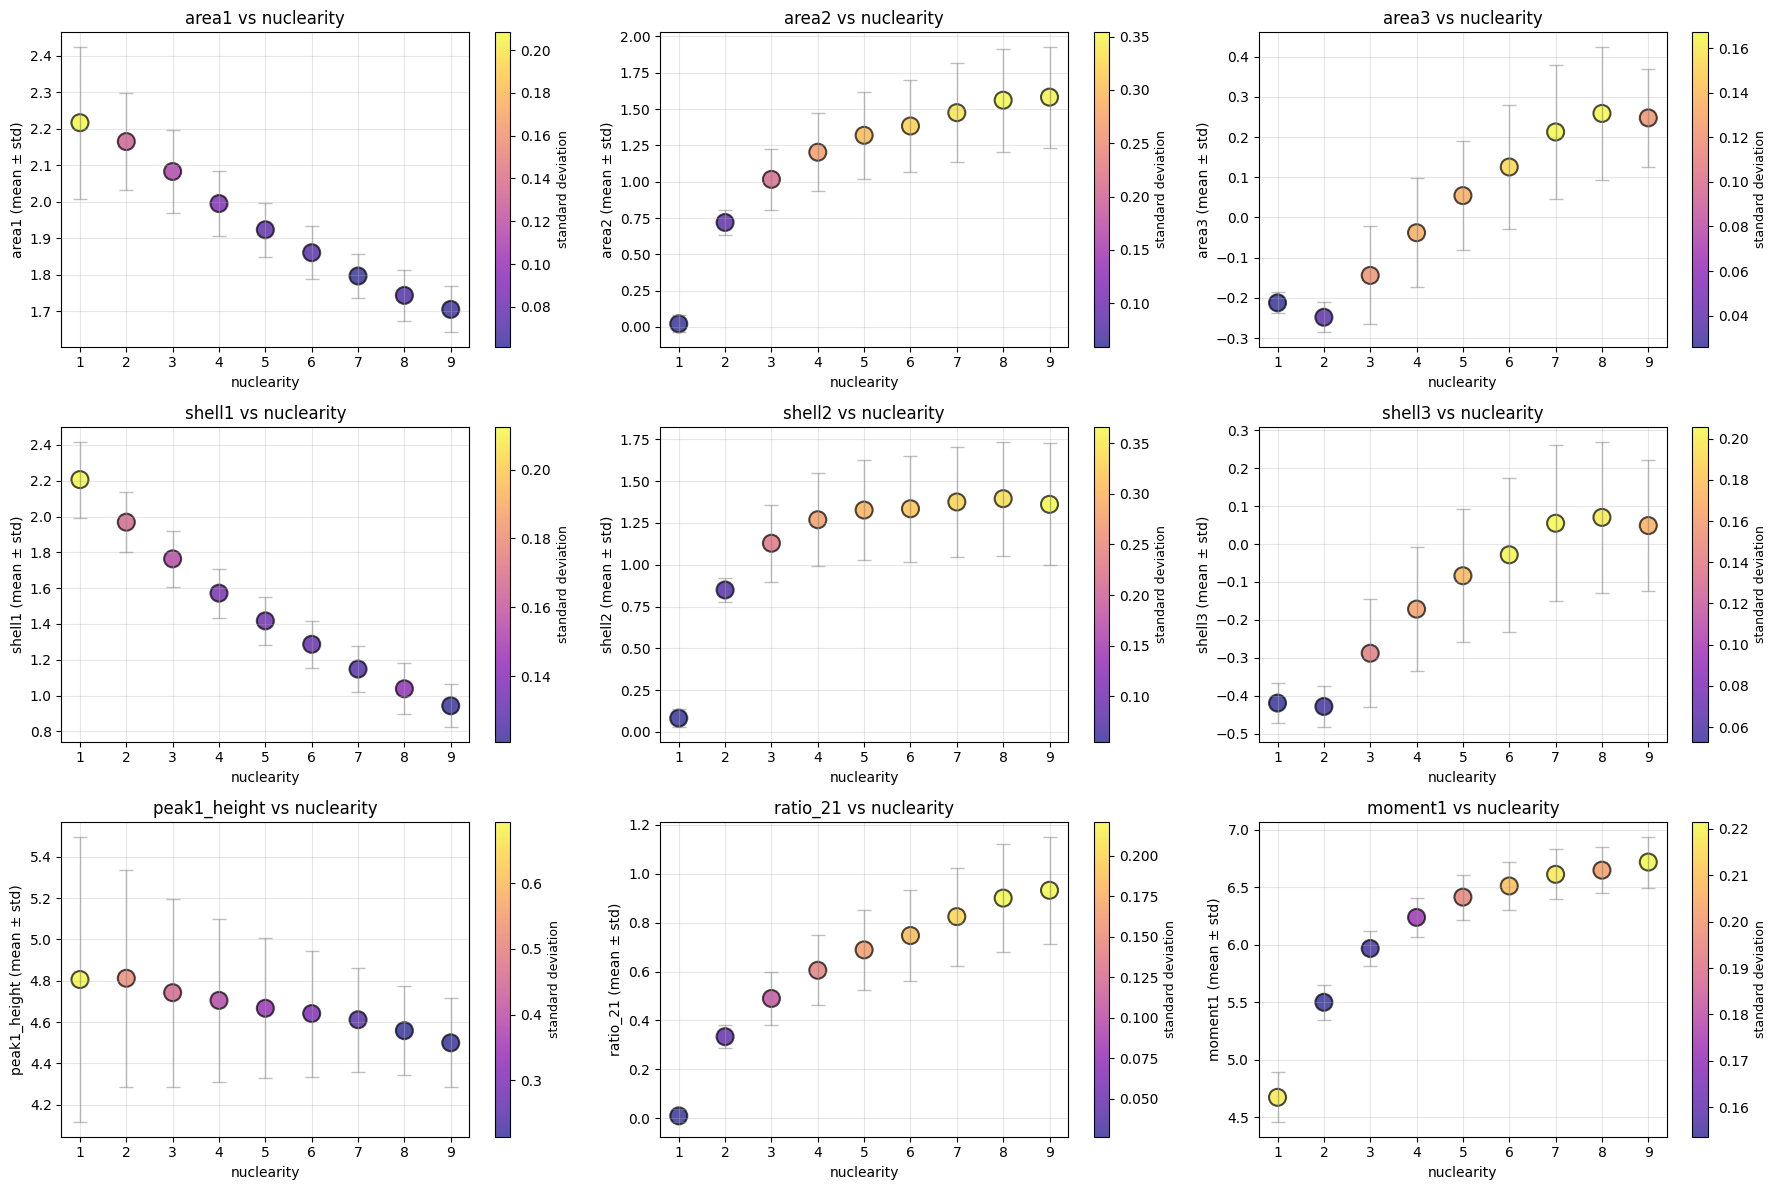

In [6]:
# Feature vs nuclearity with dispersion analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes_flat = axes.flatten()

# Calculate mean and std for each feature grouped by nuclearity
feature_dispersion = {}
nuclearity_values = sorted(features_data['nuclearity'].unique())

# Select key features for visualization
key_features = ['area1', 'area2', 'area3', 'shell1', 'shell2', 'shell3', 'peak1_height', 'ratio_21', 'moment1']

for idx, feature in enumerate(key_features):
    ax = axes_flat[idx]
    
    # Calculate mean and std for each nuclearity
    feature_means = []
    feature_stds = []
    
    for nuc in nuclearity_values:
        nuc_data = features_data[features_data['nuclearity'] == nuc][feature]
        feature_means.append(nuc_data.mean())
        feature_stds.append(nuc_data.std())
    
    # Create scatter plot: nuclearity vs feature value, colored by dispersion (std)
    scatter = ax.scatter(nuclearity_values, feature_means, 
                        c=feature_stds, cmap='plasma', s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add error bars showing std deviation
    ax.errorbar(nuclearity_values, feature_means, yerr=feature_stds, fmt='none', 
               ecolor='gray', alpha=0.5, capsize=5, linewidth=1)
    
    ax.set_xlabel('nuclearity')
    ax.set_ylabel(f'{feature} (mean ± std)')
    ax.set_title(f'{feature} vs nuclearity')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(nuclearity_values)
    
    # Add colorbar for this subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('standard deviation', fontsize=9)

# Hide any unused subplots
for j in range(len(key_features), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()


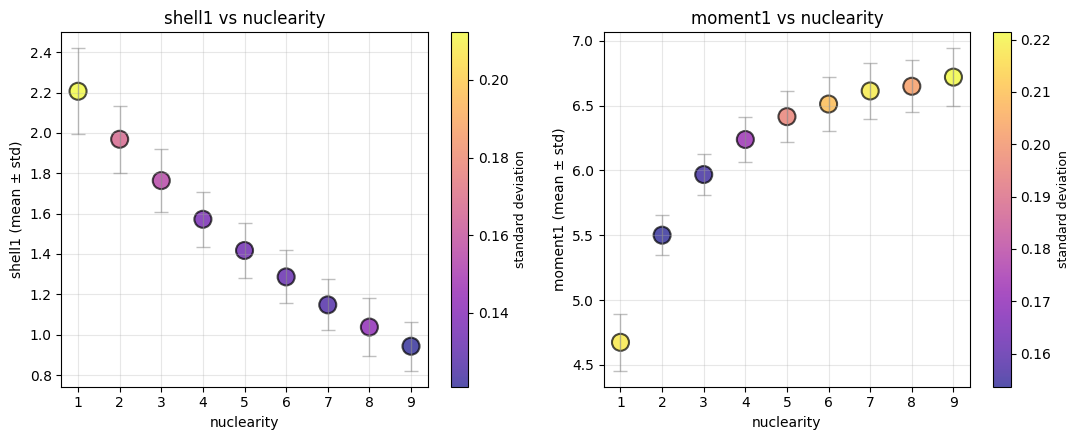

In [7]:
# Feature vs nuclearity with dispersion analysis
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes_flat = axes.flatten()

# Calculate mean and std for each feature grouped by nuclearity
feature_dispersion = {}
nuclearity_values = sorted(features_data['nuclearity'].unique())

# Select key features for visualization
key_features = ['shell1', 'moment1']

for idx, feature in enumerate(key_features):
    ax = axes_flat[idx]
    
    # Calculate mean and std for each nuclearity
    feature_means = []
    feature_stds = []
    
    for nuc in nuclearity_values:
        nuc_data = features_data[features_data['nuclearity'] == nuc][feature]
        feature_means.append(nuc_data.mean())
        feature_stds.append(nuc_data.std())
    
    # Create scatter plot: nuclearity vs feature value, colored by dispersion (std)
    scatter = ax.scatter(nuclearity_values, feature_means, 
                        c=feature_stds, cmap='plasma', s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add error bars showing std deviation
    ax.errorbar(nuclearity_values, feature_means, yerr=feature_stds, fmt='none', 
               ecolor='gray', alpha=0.5, capsize=5, linewidth=1)
    
    ax.set_xlabel('nuclearity')
    ax.set_ylabel(f'{feature} (mean ± std)')
    ax.set_title(f'{feature} vs nuclearity')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(nuclearity_values)
    
    # Add colorbar for this subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('standard deviation', fontsize=9)

plt.tight_layout()
plt.show()


## Model Training: Gradient Boosting Classifier

Feature matrix shape: (10000, 20)
Target distribution: [   0 2188 2614 2100 1433  857  472  215   95   26]
Training Gradient Boosting Classifier on PDF features...



Gradient Boosting Classification Results (PDF features):
Accuracy: 0.960
F1-score (weighted): 0.959
F1-score (macro): 0.766

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       438
           2       1.00      1.00      1.00       523
           3       0.99      1.00      1.00       420
           4       0.92      0.98      0.95       287
           5       0.90      0.86      0.88       171
           6       0.81      0.76      0.78        94
           7       0.78      0.65      0.71        43
           8       0.58      0.58      0.58        19
           9       0.00      0.00      0.00         5

    accuracy                           0.96      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.96      0.96      0.96      2000




Cross-validation F1-scores: [0.95860401 0.95107283 0.96021459 0.95485766 0.95006801]
Mean CV F1-score: 0.955 (+/- 0.008)


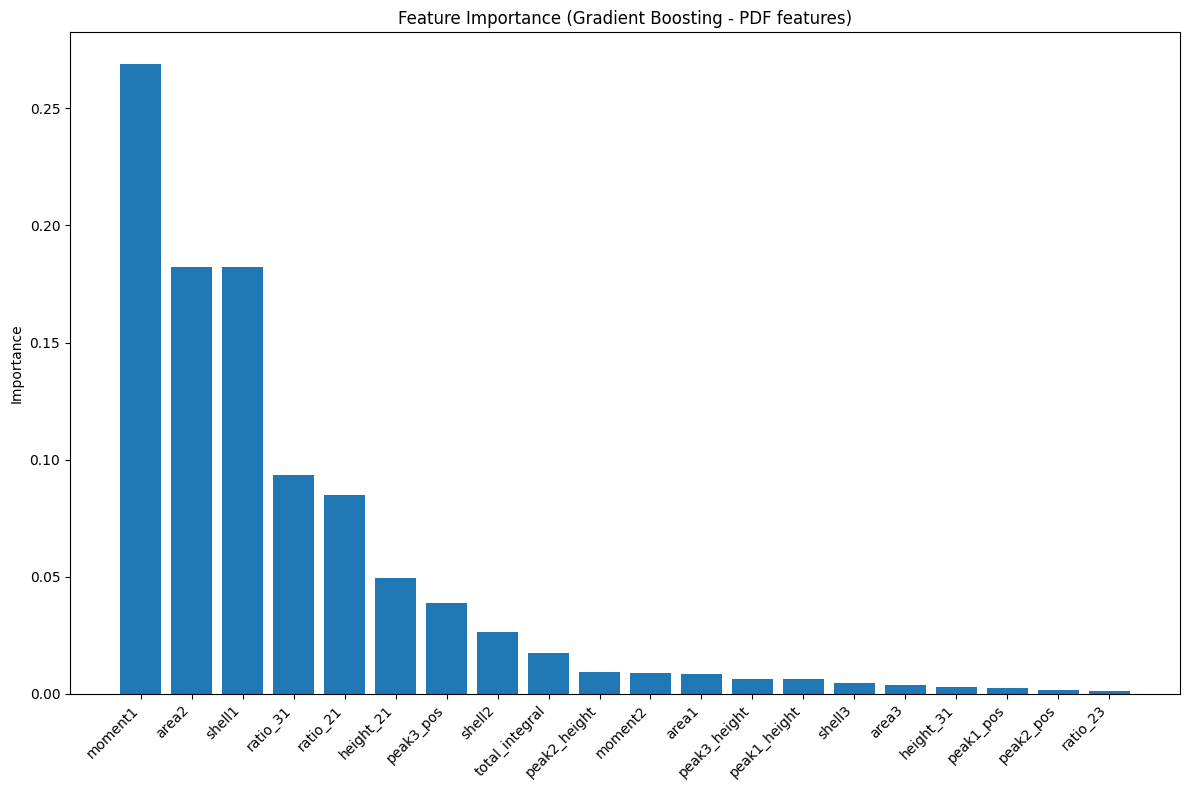


Top 5 most important PDF features:
1. moment1: 0.269
2. area2: 0.182
3. shell1: 0.182
4. ratio_31: 0.093
5. ratio_21: 0.085


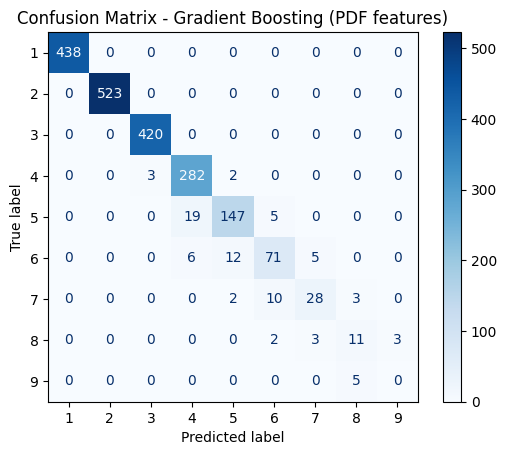

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Prepare data for classification
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=6,
    random_state=42
)

print("Training Gradient Boosting Classifier on PDF features...")
gb_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test_scaled)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\nGradient Boosting Classification Results (PDF features):")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score (weighted): {f1_weighted:.3f}")
print(f"F1-score (macro): {f1_macro:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Cross-validation performance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_classifier, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
print(f"\nCross-validation F1-scores: {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Feature importance
feature_importance = gb_classifier.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance)[::-1]
plt.bar(range(len(feature_importance)), feature_importance[indices])
plt.xticks(range(len(feature_importance)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Gradient Boosting - PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important PDF features:")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance[idx]:.3f}")

# Confusion matrix
classes = sorted(np.unique(y))
conf_matrix = confusion_matrix(y_test, y_pred, labels=classes)
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
display.plot(cmap='Blues', values_format='d', colorbar=True)
display.ax_.set_title('Confusion Matrix - Gradient Boosting (PDF features)')
plt.show()

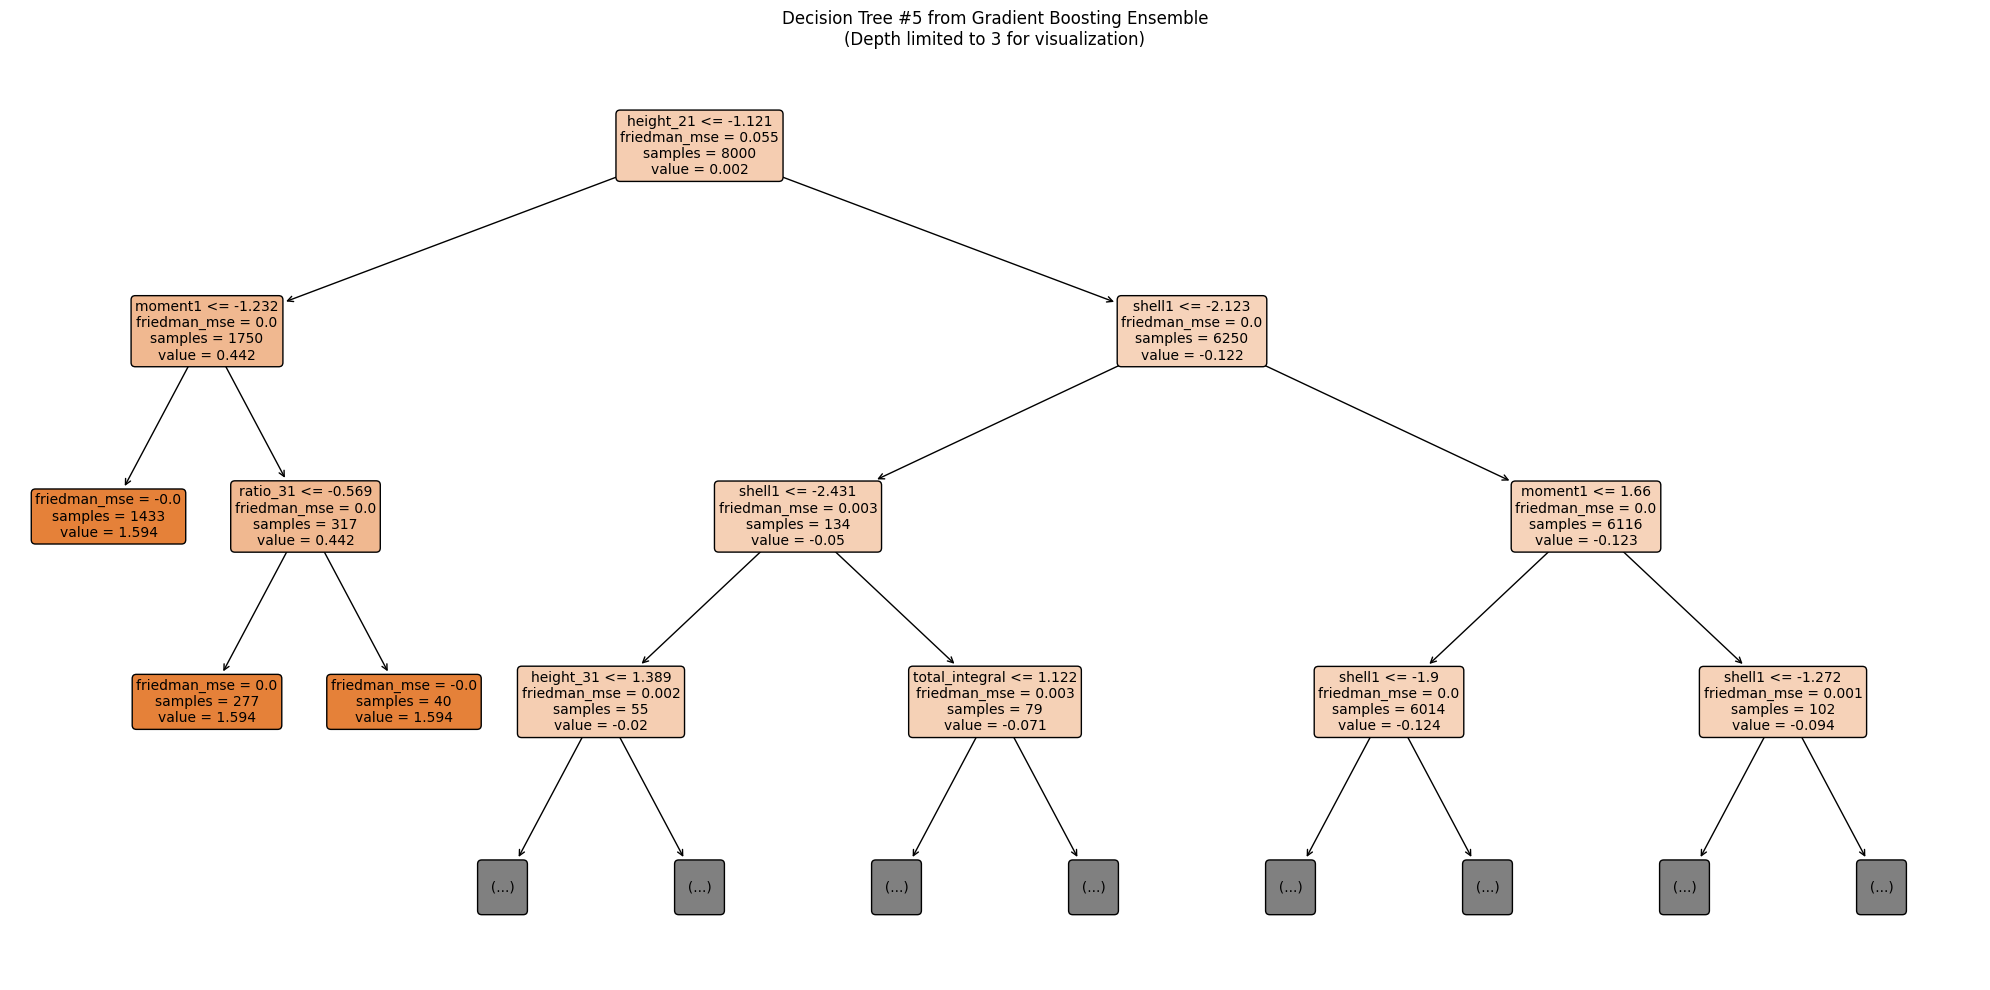

Tree #5 details:
  Number of nodes: 67
  Maximum depth: 6
  Number of leaves: 34


In [9]:
# Visualize a single tree from the Gradient Boosting ensemble
from sklearn.tree import plot_tree

# Select a tree to visualize (e.g., the 5th estimator)
tree_index = 4  # 5th tree (0-indexed)

plt.figure(figsize=(20, 10))
plot_tree(
    gb_classifier.estimators_[tree_index, 0],
    feature_names=feature_names_clean,
    class_names=[str(i) for i in sorted(np.unique(y))],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Limit depth for visualization clarity
)
plt.title(f'Decision Tree #{tree_index + 1} from Gradient Boosting Ensemble\n(Depth limited to 3 for visualization)')
plt.tight_layout()
plt.show()

print(f"Tree #{tree_index + 1} details:")
print(f"  Number of nodes: {gb_classifier.estimators_[tree_index, 0].tree_.node_count}")
print(f"  Maximum depth: {gb_classifier.estimators_[tree_index, 0].tree_.max_depth}")
print(f"  Number of leaves: {gb_classifier.estimators_[tree_index, 0].tree_.n_leaves}")

## Model Training: Random Forest Classifier

Training Random Forest Classifier with hyperparameter tuning...
Fitting 3 folds for each of 48 candidates, totalling 144 fits


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV score: 0.944

Random Forest Classification Results (PDF features):
Accuracy: 0.947
F1-score (weighted): 0.944
F1-score (macro): 0.715

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       438
           2       1.00      1.00      1.00       523
           3       1.00      1.00      1.00       420
           4       0.91      0.98      0.94       287
           5       0.83      0.81      0.82       171
           6       0.70      0.70      0.70        94
           7       0.63      0.44      0.52        43
           8       0.50      0.42      0.46        19
           9       0.00      0.00      0.00         5

    accuracy                           0.95      2000
   macro avg       0.73      0.71      0.72      2000
weighted avg       0.94      0.95      0.94   

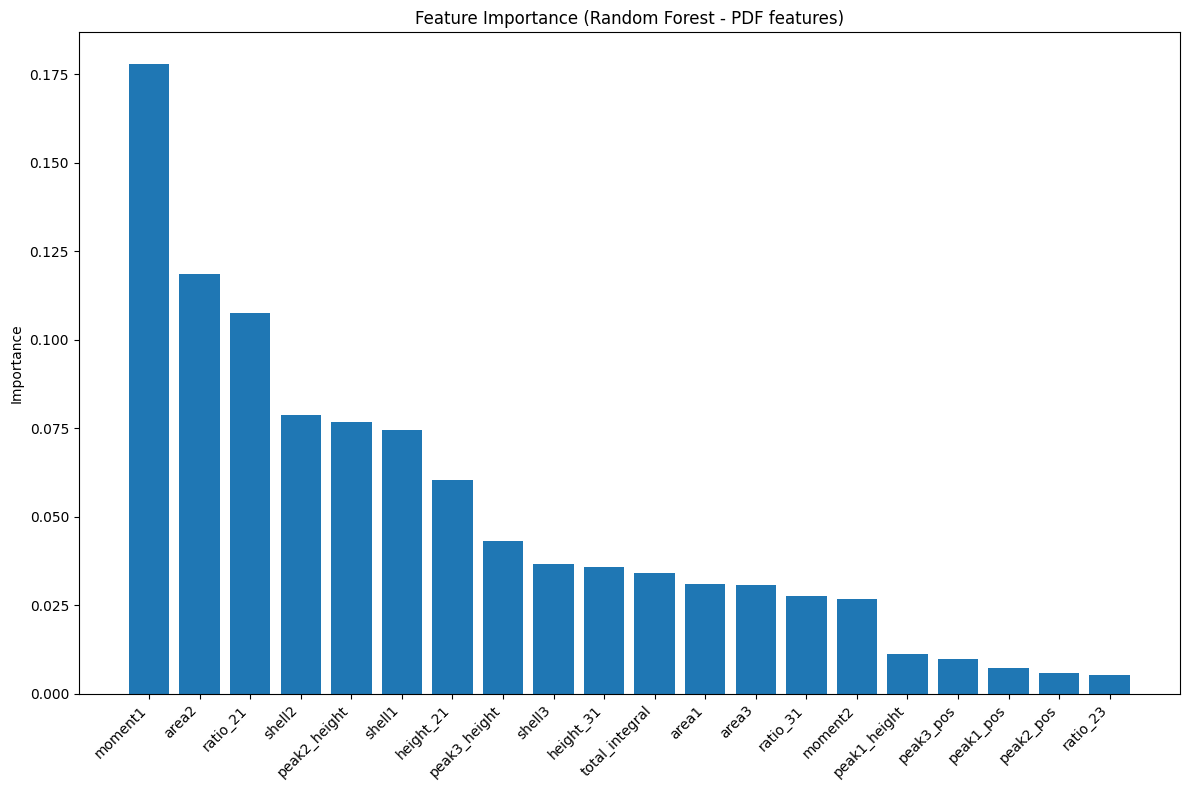


Top 5 most important PDF features (Random Forest):
1. moment1: 0.178
2. area2: 0.119
3. ratio_21: 0.108
4. shell2: 0.079
5. peak2_height: 0.077


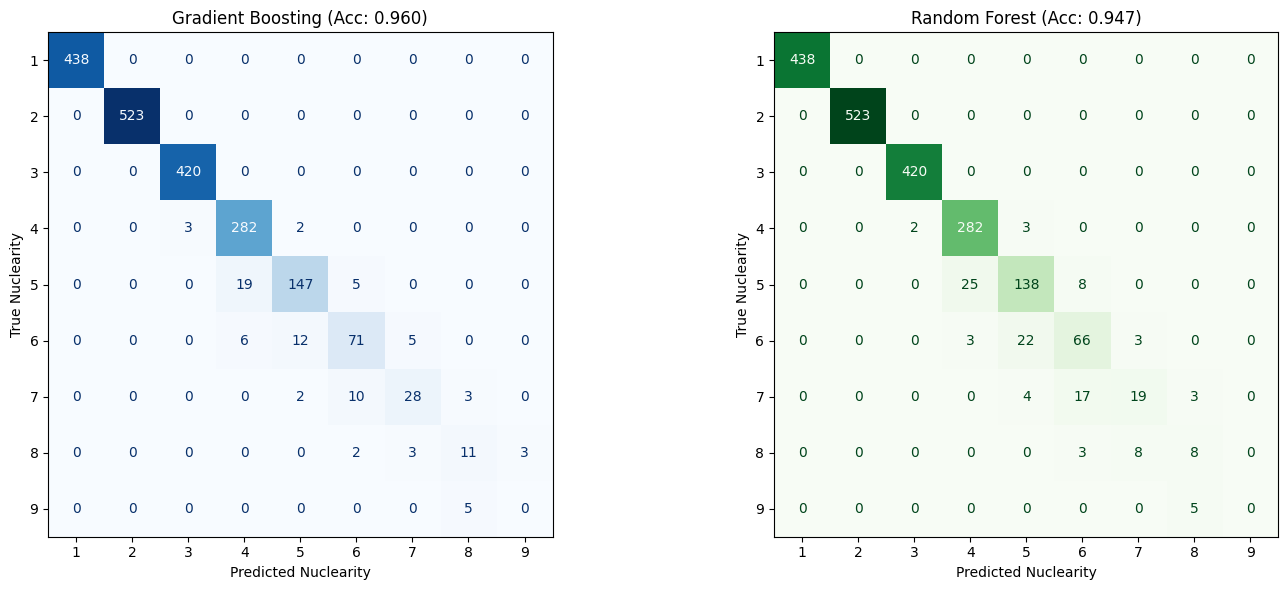


Per-class accuracy comparison:
Class      GB Precision    RF Precision    GB Recall    RF Recall   
----------------------------------------------------------------------
1          1.000           1.000           1.000        1.000       
2          1.000           1.000           1.000        1.000       
3          0.993           0.995           1.000        1.000       
4          0.919           0.910           0.983        0.983       
5          0.902           0.826           0.860        0.807       
6          0.807           0.702           0.755        0.702       
7          0.778           0.633           0.651        0.442       
8          0.579           0.500           0.579        0.421       
9          0.000           0.000           0.000        0.000       


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Training Random Forest Classifier with hyperparameter tuning...")

# Define parameter grid for optimization
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_classifier = RandomForestClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    rf_classifier, 
    param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Get best model
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Make predictions with best model
y_pred_rf = best_rf.predict(X_test_scaled)

# Calculate classification metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"\nRandom Forest Classification Results (PDF features):")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"F1-score (weighted): {f1_weighted_rf:.3f}")
print(f"F1-score (macro): {f1_macro_rf:.3f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Feature importance analysis
feature_importance_rf = best_rf.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.bar(range(len(feature_importance_rf)), feature_importance_rf[indices])
plt.xticks(range(len(feature_importance_rf)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Random Forest - PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important PDF features (Random Forest):")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance_rf[idx]:.3f}")

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
classes = sorted(np.unique(y))

# Gradient Boosting confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred, labels=classes)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_gb, display_labels=classes).plot(
    ax=axes[0], cmap='Blues', values_format='d', colorbar=False
)
axes[0].set_xlabel('Predicted Nuclearity')
axes[0].set_ylabel('True Nuclearity')
axes[0].set_title(f'Gradient Boosting (Acc: {accuracy:.3f})')

# Random Forest confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf, labels=classes)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=classes).plot(
    ax=axes[1], cmap='Greens', values_format='d', colorbar=False
)
axes[1].set_xlabel('Predicted Nuclearity')
axes[1].set_ylabel('True Nuclearity')
axes[1].set_title(f'Random Forest (Acc: {accuracy_rf:.3f})')

plt.tight_layout()
plt.show()

# Calculate per-class accuracy
from sklearn.metrics import precision_score, recall_score

unique_classes = sorted(np.unique(y))
print(f"\nPer-class accuracy comparison:")
print(f"{'Class':<10} {'GB Precision':<15} {'RF Precision':<15} {'GB Recall':<12} {'RF Recall':<12}")
print("-" * 70)

for cls in unique_classes:
    gb_prec = precision_score(y_test == cls, y_pred == cls, zero_division=0)
    rf_prec = precision_score(y_test == cls, y_pred_rf == cls, zero_division=0)
    gb_rec = recall_score(y_test == cls, y_pred == cls, zero_division=0)
    rf_rec = recall_score(y_test == cls, y_pred_rf == cls, zero_division=0)
    print(f"{cls:<10} {gb_prec:<15.3f} {rf_prec:<15.3f} {gb_rec:<12.3f} {rf_rec:<12.3f}")

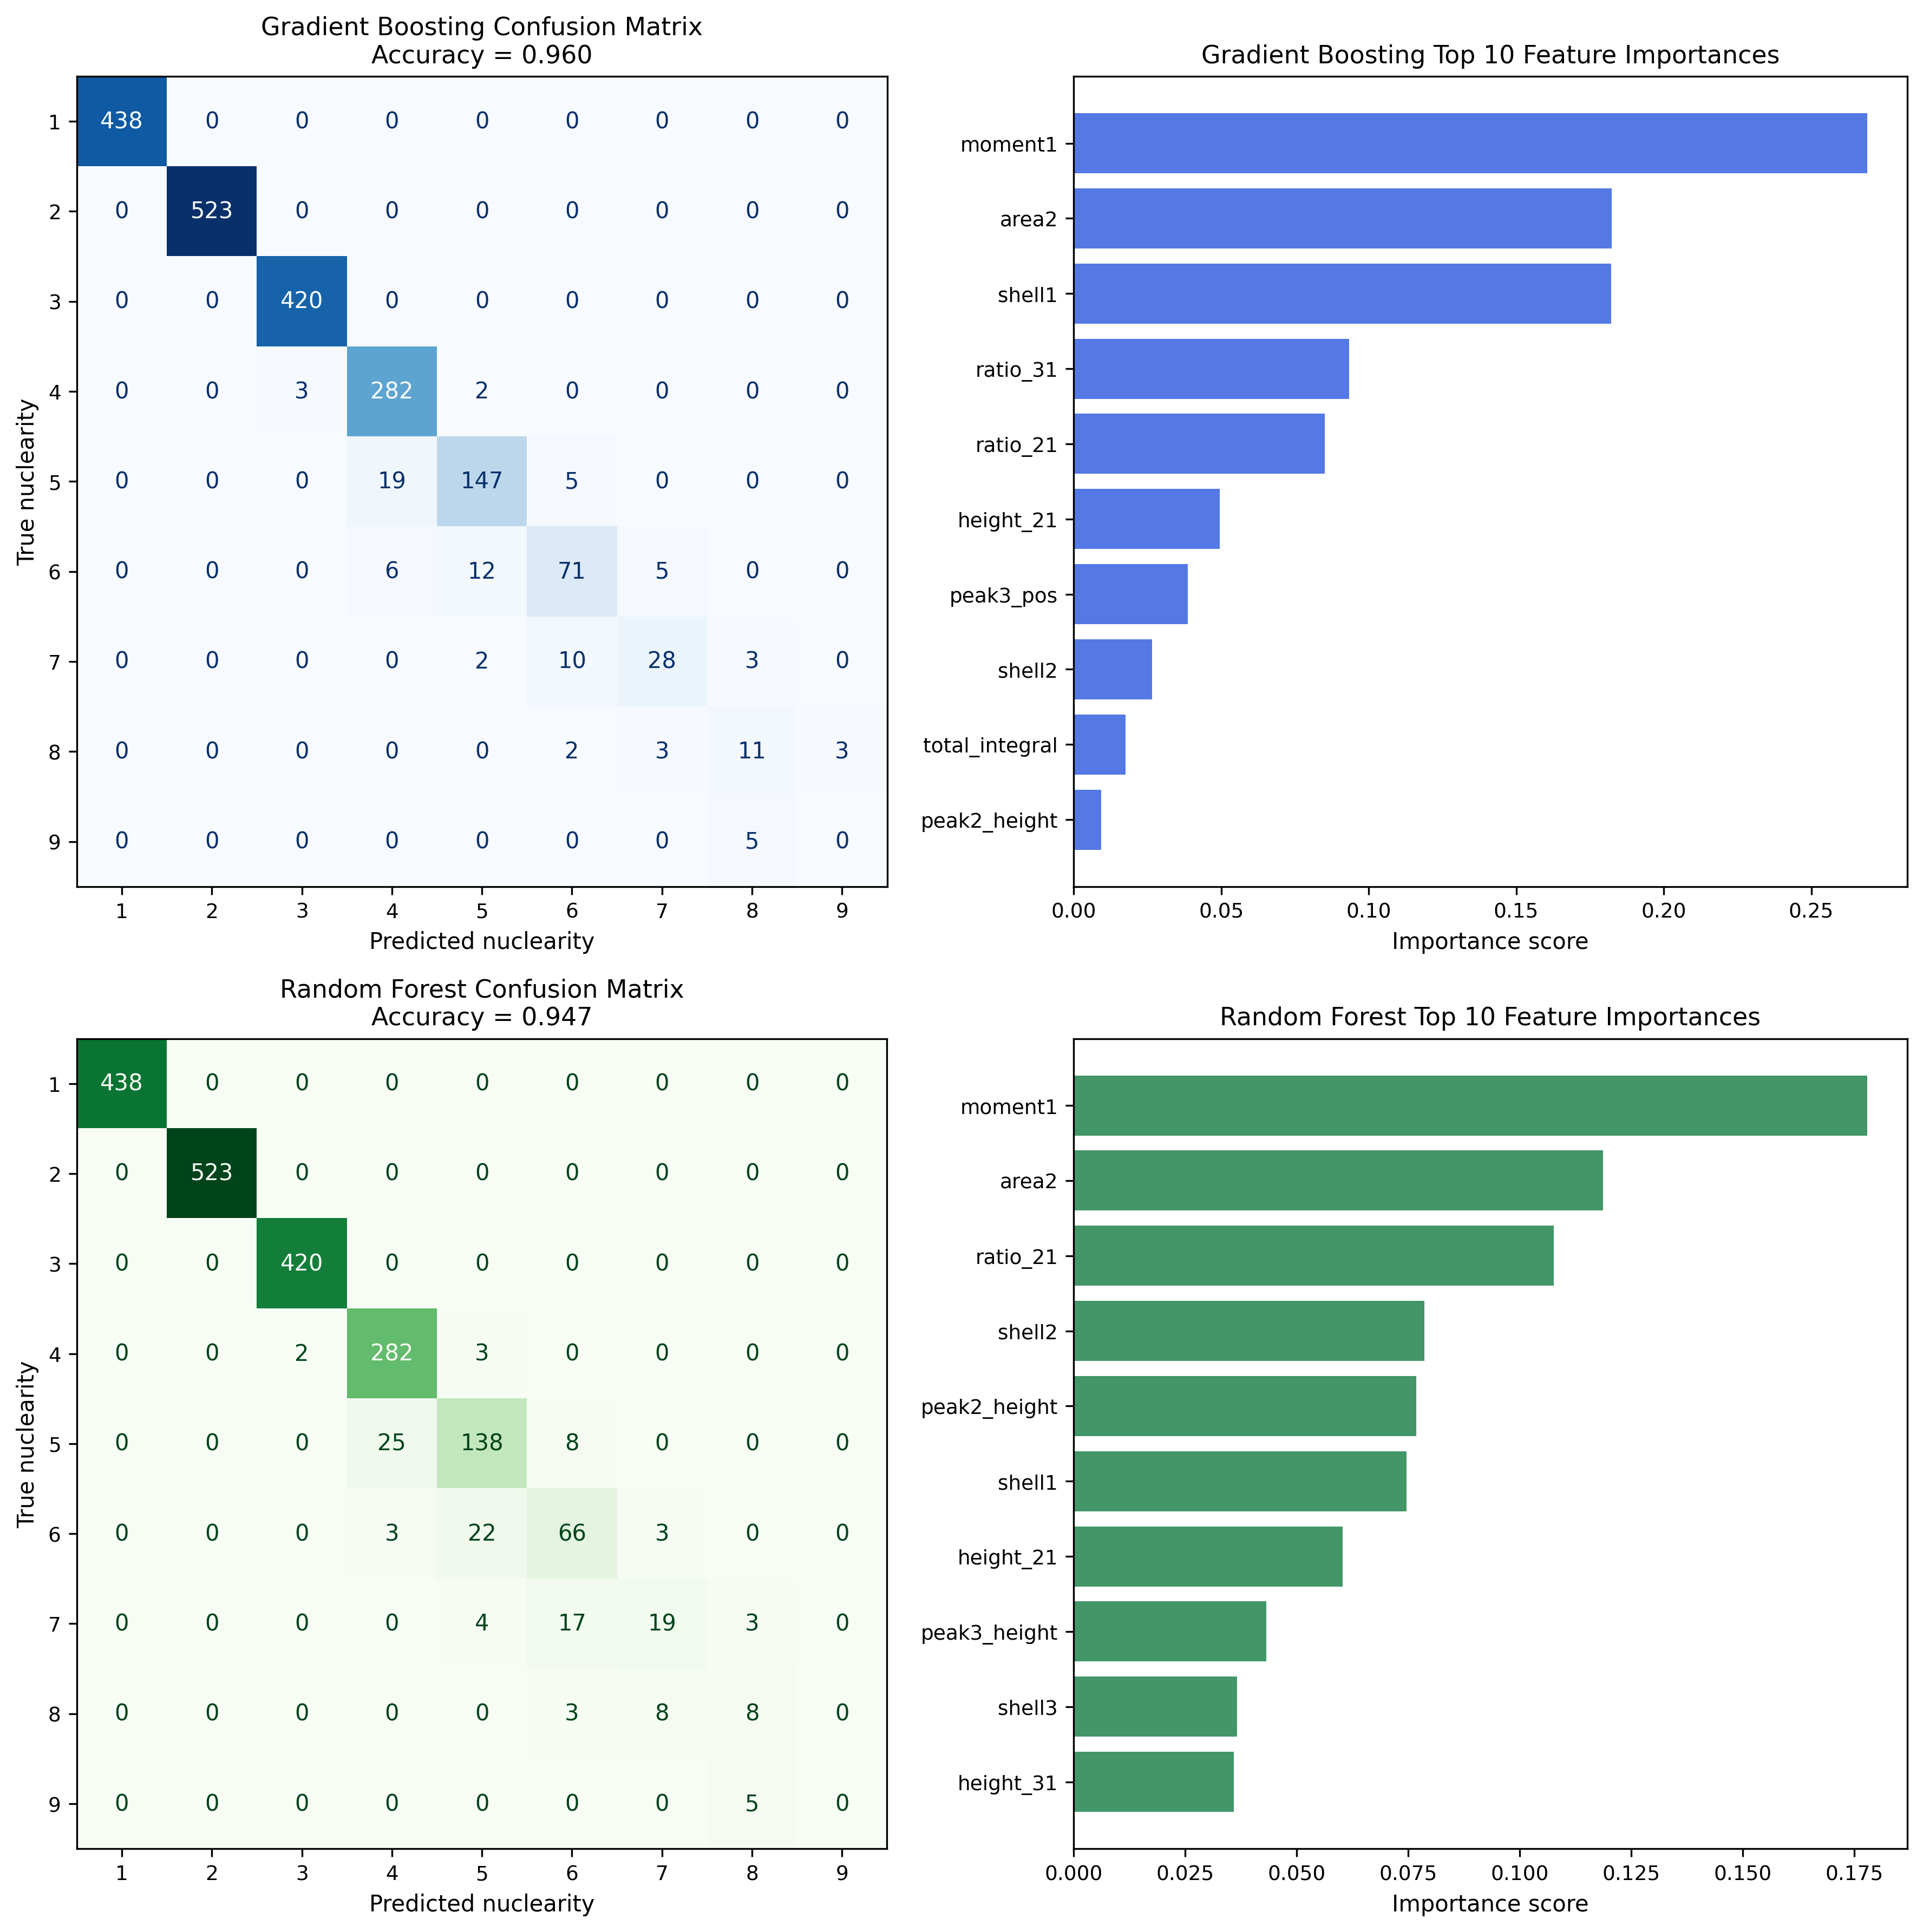

In [11]:
# Plot GB vs RF comparison together

# Guard checks for required upstream objects
required_vars = ['gb_classifier', 'best_rf', 'y_test', 'y_pred', 'y_pred_rf']
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Run the model training cells first. Missing variables: " + ", ".join(missing_vars)
    )

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

# Robust class extraction (no dependency on global y)
if 'y' in globals():
    classes = sorted(np.unique(y))
else:
    classes = sorted(np.unique(np.concatenate([y_test, y_pred, y_pred_rf])))

# Robust feature names
if 'feature_names' in globals() and len(feature_names) == gb_classifier.n_features_in_ + 1:
    feature_names_clean = feature_names[1:]
elif 'features_data' in globals() and 'nuclearity' in features_data.columns:
    feature_names_clean = [col for col in features_data.columns if col != 'nuclearity']
else:
    feature_names_clean = [f'feature_{i}' for i in range(gb_classifier.n_features_in_)]

# Metrics fallback
if 'accuracy' not in globals():
    accuracy = accuracy_score(y_test, y_pred)
if 'accuracy_rf' not in globals():
    accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Confusion matrices
cm_gb = confusion_matrix(y_test, y_pred, labels=classes)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=classes)

# Feature importances (sorted)
gb_importance = pd.Series(gb_classifier.feature_importances_, index=feature_names_clean).sort_values(ascending=False)
rf_importance = pd.Series(best_rf.feature_importances_, index=feature_names_clean).sort_values(ascending=False)
top_n = 10

# Build 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=300)
ax_cm_gb, ax_cm_rf = axes[0, 0], axes[1, 0]
ax_fi_gb, ax_fi_rf = axes[0, 1], axes[1, 1]

# 1) Confusion matrices
ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=classes).plot(
    ax=ax_cm_gb, cmap='Blues', values_format='d', colorbar=False
)
ax_cm_gb.set_title(f'Gradient Boosting Confusion Matrix\nAccuracy = {accuracy:.3f}')
ax_cm_gb.set_xlabel('Predicted nuclearity')
ax_cm_gb.set_ylabel('True nuclearity')

ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=classes).plot(
    ax=ax_cm_rf, cmap='Greens', values_format='d', colorbar=False
)
ax_cm_rf.set_title(f'Random Forest Confusion Matrix\nAccuracy = {accuracy_rf:.3f}')
ax_cm_rf.set_xlabel('Predicted nuclearity')
ax_cm_rf.set_ylabel('True nuclearity')

# 2) Feature importances (top N)
gb_top = gb_importance.head(top_n).sort_values(ascending=True)
rf_top = rf_importance.head(top_n).sort_values(ascending=True)

ax_fi_gb.barh(gb_top.index, gb_top.values, color='royalblue', alpha=0.9)
ax_fi_gb.set_title(f'Gradient Boosting Top {top_n} Feature Importances')
ax_fi_gb.set_xlabel('Importance score')

ax_fi_rf.barh(rf_top.index, rf_top.values, color='seagreen', alpha=0.9)
ax_fi_rf.set_title(f'Random Forest Top {top_n} Feature Importances')
ax_fi_rf.set_xlabel('Importance score')

fig.tight_layout()
plt.show()

## Model Training: Bayesian Classification

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import PolynomialFeatures

# Strategy 1: Feature Selection for Naive Bayes
print("1. Feature Selection for Naive Bayes")

def seeded_mutual_info(X_values, y_values):
    return mutual_info_classif(X_values, y_values, random_state=RANDOM_SEED)

# Use mutual information to select most informative features
selector = SelectKBest(score_func=seeded_mutual_info, k=10)  # Select top 10 features
X_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = np.array(feature_names_clean)[selector.get_support()]
print(f"Selected features: {list(selected_features)}")

# Train Naive Bayes on selected features
nb_improved = GaussianNB()
nb_improved.fit(X_selected, y_train)
y_pred_nb_improved = nb_improved.predict(X_test_selected)

accuracy_nb_improved = accuracy_score(y_test, y_pred_nb_improved)
f1_nb_improved = f1_score(y_test, y_pred_nb_improved, average='weighted')

print(f"Improved Naive Bayes: {accuracy_nb_improved:.3f} accuracy, {f1_nb_improved:.3f} F1")

# Strategy 2: Tuned Logistic Regression
print("\n2. Hyperparameter Tuning for Logistic Regression")

# Grid search for optimal regularization
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [5000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_SEED, multi_class='ovr'),
    param_grid_lr,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print(f"Best LogReg params: {lr_grid.best_params_}")

y_pred_lr_improved = lr_grid.predict(X_test_scaled)
accuracy_lr_improved = accuracy_score(y_test, y_pred_lr_improved)
f1_lr_improved = f1_score(y_test, y_pred_lr_improved, average='weighted')

print(f"Improved Logistic Regression: {accuracy_lr_improved:.3f} accuracy, {f1_lr_improved:.3f} F1")

# Strategy 3: Polynomial Features
print("\n3. Feature Engineering - Polynomial Features")

# Create polynomial features for top 5 most important features
feature_importance_rf = best_rf.feature_importances_
top_5_indices = np.argsort(feature_importance_rf)[-5:]
X_train_top5 = X_train_scaled[:, top_5_indices]
X_test_top5 = X_test_scaled[:, top_5_indices]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top5)
X_test_poly = poly.transform(X_test_top5)

print(f"Polynomial features: {X_train_poly.shape[1]} features from top 5")

# Train LogReg on polynomial features
lr_poly = LogisticRegression(C=1.0, random_state=RANDOM_SEED, max_iter=5000)
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_test_poly)

accuracy_lr_poly = accuracy_score(y_test, y_pred_lr_poly)
f1_lr_poly = f1_score(y_test, y_pred_lr_poly, average='weighted')

print(f"LogReg + Polynomial Features: {accuracy_lr_poly:.3f} accuracy, {f1_lr_poly:.3f} F1")

# Strategy 4: Ensemble
print("\n4. Ensemble of Bayesian Methods")

bayesian_ensemble = VotingClassifier([
    ('lr_tuned', lr_grid.best_estimator_),
    ('nb', GaussianNB())
], voting='soft')

bayesian_ensemble.fit(X_train_scaled, y_train)
y_pred_ensemble = bayesian_ensemble.predict(X_test_scaled)

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='weighted')

print(f"Bayesian Ensemble: {accuracy_ensemble:.3f} accuracy, {f1_ensemble:.3f} F1")

1. Feature Selection for Naive Bayes


Selected features: ['area1', 'area2', 'area3', 'ratio_21', 'ratio_31', 'peak3_height', 'height_21', 'height_31', 'shell1', 'moment1']
Improved Naive Bayes: 0.857 accuracy, 0.853 F1

2. Hyperparameter Tuning for Logistic Regression


Best LogReg params: {'C': 100, 'max_iter': 5000, 'solver': 'lbfgs'}
Improved Logistic Regression: 0.849 accuracy, 0.844 F1

3. Feature Engineering - Polynomial Features
Polynomial features: 15 features from top 5


LogReg + Polynomial Features: 0.895 accuracy, 0.890 F1

4. Ensemble of Bayesian Methods


Bayesian Ensemble: 0.826 accuracy, 0.810 F1


## Model Training: Simple Neural Network

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(RANDOM_SEED)

# Prepare data for neural network
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Neural network input: {X.shape[1]} PDF features")
print(f"Classes: {sorted(np.unique(y))}")

num_classes = len(np.unique(y))
y_categorical = keras.utils.to_categorical(y - 1, num_classes)  # -1 because nuclearity starts at 1

X_train, X_test, y_train, y_test, y_cat_train, y_cat_test = train_test_split(
    X, y, y_categorical, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Building neural network for PDF-based nuclearity classification...")

model = keras.Sequential([
    # Input layer with dropout for regularization
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layers with decreasing size
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer for classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile with appropriate loss for classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'categorical_crossentropy']
)

print(f"Model architecture:")
model.summary()

# Training with early stopping and learning rate reduction
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
]

print("\nTraining neural network...")
num_epochs = 150
history = model.fit(
    X_train_scaled, y_cat_train,
    batch_size=64,
    epochs=num_epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluation and predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1) + 1  # +1 to convert back to nuclearity

# Calculate classification metrics
accuracy_nn = accuracy_score(y_test, y_pred_classes)
f1_weighted_nn = f1_score(y_test, y_pred_classes, average='weighted')
f1_macro_nn = f1_score(y_test, y_pred_classes, average='macro')

print(f"\nNeural Network Classification Results (PDF features):")
print(f"Accuracy: {accuracy_nn:.3f}")
print(f"F1-score (weighted): {f1_weighted_nn:.3f}")
print(f"F1-score (macro): {f1_macro_nn:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes, zero_division=0))


Neural network input: 20 PDF features
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Building neural network for PDF-based nuclearity classification...
Model architecture:
Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 128)               2688      


 batch_normalization (BatchN  (None, 128)              512       


...

 72/100 [====================>.........] - ETA: 0s - loss: 0.1096 - accuracy: 0.9577 - categorical_crossentropy: 0.1096

100/100 [==============================] - 0s 2ms/step - loss: 0.1064 - accuracy: 0.9602 - categorical_crossentropy: 0.1064 - val_loss: 0.0846 - val_accuracy: 0.9737 - val_categorical_crossentropy: 0.0846 - lr: 1.2500e-04


 1/63 [..............................] - ETA: 7s

63/63 [==============================] - 0s 484us/step



Neural Network Classification Results (PDF features):
Accuracy: 0.973
F1-score (weighted): 0.972
F1-score (macro): 0.791

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       438
           2       1.00      1.00      1.00       523
           3       0.99      1.00      1.00       420
           4       0.97      0.98      0.98       287
           5       0.94      0.93      0.93       171
           6       0.85      0.87      0.86        94
           7       0.75      0.77      0.76        43
           8       0.61      0.58      0.59        19
           9       0.00      0.00      0.00         5

    accuracy                           0.97      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.97      0.97      0.97      2000



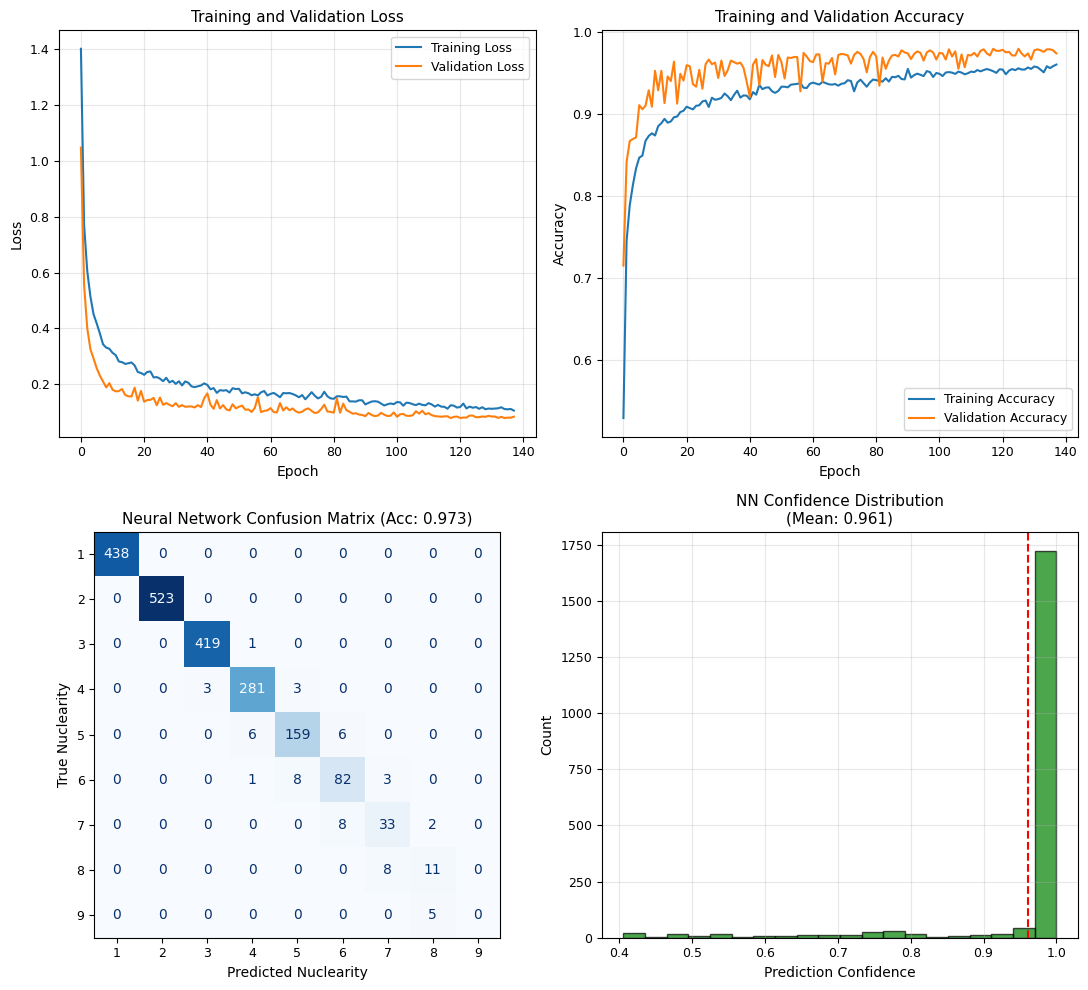

In [14]:
# Visualization: Training history and confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

# Training history - Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
classes = sorted(np.unique(y))
conf_matrix_nn = confusion_matrix(y_test, y_pred_classes, labels=classes)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_nn, display_labels=classes).plot(
    ax=axes[1, 0], cmap='Blues', values_format='d', colorbar=False
)
axes[1, 0].set_xlabel('Predicted Nuclearity')
axes[1, 0].set_ylabel('True Nuclearity')
axes[1, 0].set_title(f'Neural Network Confusion Matrix (Acc: {accuracy_nn:.3f})')

# Prediction confidence distribution
confidence_scores = np.max(y_pred_prob, axis=1)
axes[1, 1].hist(confidence_scores, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_xlabel('Prediction Confidence')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'NN Confidence Distribution\n(Mean: {confidence_scores.mean():.3f})')
axes[1, 1].axvline(confidence_scores.mean(), color='red', linestyle='--')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Permutation explainer:  32%|████████▋                  | 96/300 [00:00<?, ?it/s]

Permutation explainer:  33%|██████▎            | 99/300 [00:10<00:13, 14.39it/s]

Permutation explainer:  34%|██████            | 101/300 [00:10<00:18, 10.88it/s]

Permutation explainer:  34%|██████▏           | 103/300 [00:10<00:18, 10.84it/s]

...

Permutation explainer:  99%|█████████████████▊| 296/300 [00:27<00:00, 10.75it/s]

Permutation explainer:  99%|█████████████████▉| 298/300 [00:28<00:00, 10.82it/s]

Permutation explainer: 100%|██████████████████| 300/300 [00:28<00:00, 10.89it/s]

Permutation explainer: 301it [00:28,  7.23it/s]                                 


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


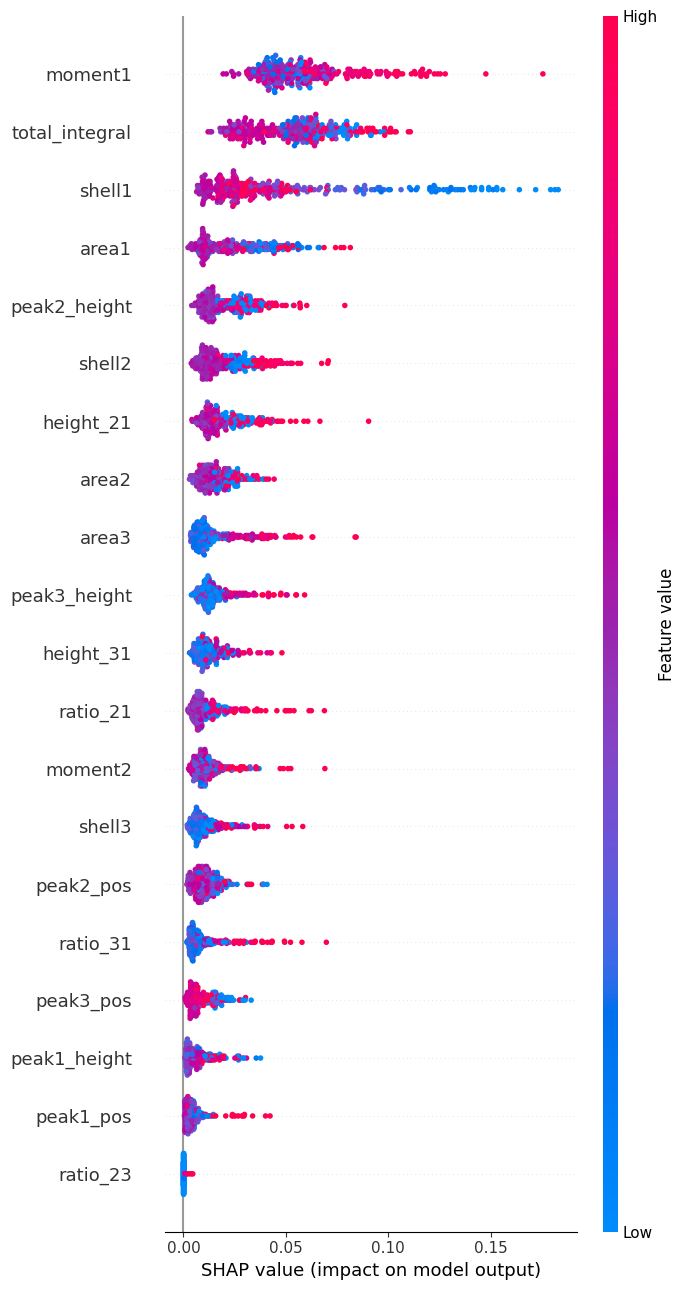

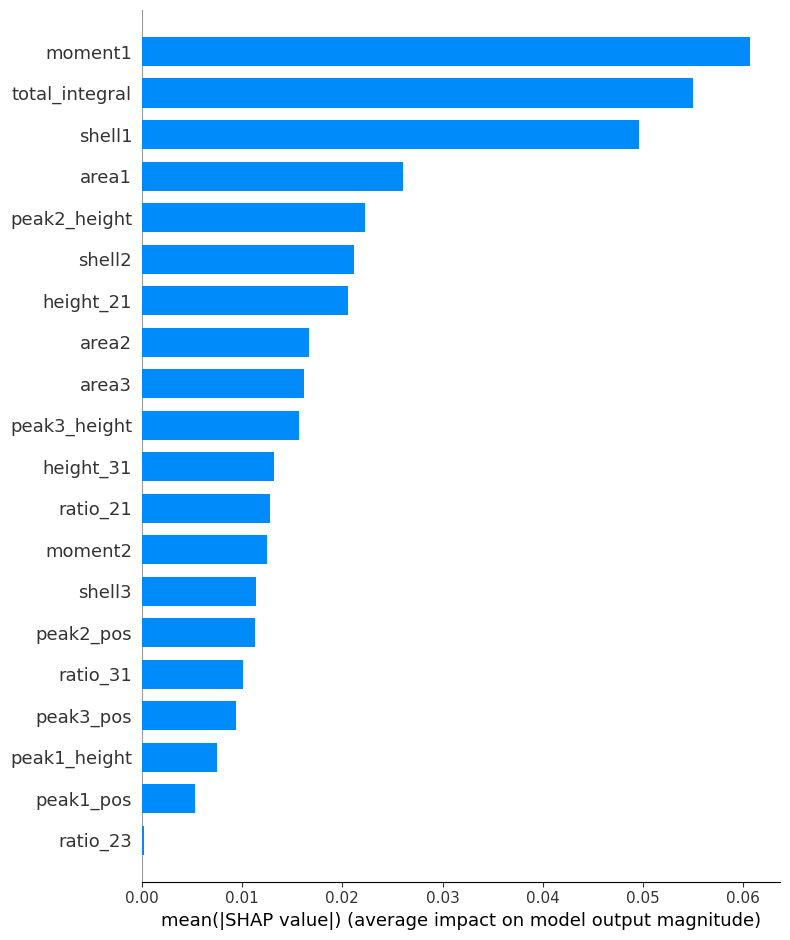

In [15]:
# SHAP explanations for the neural network
try:
    import shap
except ImportError as exc:
    raise ImportError("Install shap (pip install shap) before running this cell.") from exc

rng = np.random.default_rng(42)
background_size = min(200, X_train_scaled.shape[0])
sample_size = min(300, X_test_scaled.shape[0])

background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
sample_idx = rng.choice(X_test_scaled.shape[0], size=sample_size, replace=False)

background = X_train_scaled[background_idx]
X_shap = X_test_scaled[sample_idx]

# Build SHAP explainer for the trained Keras model
explainer = shap.Explainer(model, background, feature_names=feature_names_clean)
shap_values = explainer(X_shap)

# For multi-class outputs, summarize by mean absolute contribution per feature
if hasattr(shap_values, "values") and shap_values.values.ndim == 3:
    shap_values_mean = shap.Explanation(
        values=np.mean(np.abs(shap_values.values), axis=2),
        base_values=np.mean(shap_values.base_values, axis=1) if shap_values.base_values.ndim == 2 else shap_values.base_values,
        data=shap_values.data,
        feature_names=shap_values.feature_names,
    )
    shap_to_plot = shap_values_mean
else:
    shap_to_plot = shap_values

# Summary plots
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, show=True, plot_size=(7,13))
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, plot_type="bar", show=True)

## Final Performance Comparison

In [16]:
print(f"\n" + "="*70)
print("FINAL ALGORITHM PERFORMANCE COMPARISON (PDF Features)")
print("="*70)
print(f"{'Algorithm':<35} {'Accuracy':<12} {'F1-Weighted':<12}")
print("-"*70)
print(f"{'Neural Network':<35} {accuracy_nn:.3f}        {f1_weighted_nn:.3f}")
print(f"{'Gradient Boosting':<35} {accuracy:.3f}        {f1_weighted:.3f}")
print(f"{'Random Forest':<35} {accuracy_rf:.3f}        {f1_weighted_rf:.3f}")
print(f"{'LogReg + Polynomial':<35} {accuracy_lr_poly:.3f}        {f1_lr_poly:.3f}")
print(f"{'Bayesian Ensemble':<35} {accuracy_ensemble:.3f}        {f1_ensemble:.3f}")
print(f"{'Naive Bayes (selected)':<35} {accuracy_nb_improved:.3f}        {f1_nb_improved:.3f}")
print(f"{'Tuned Logistic Regression':<35} {accuracy_lr_improved:.3f}        {f1_lr_improved:.3f}")
print("="*70)

# Identify best performing algorithms
algorithms = ['Gradient Boosting', 'Random Forest', 'Naive Bayes (improved)', 
              'Tuned LogReg', 'LogReg+Poly', 'Bayesian Ensemble', 'Neural Network']
accuracies = [accuracy, accuracy_rf, accuracy_nb_improved, 
              accuracy_lr_improved, accuracy_lr_poly, accuracy_ensemble, accuracy_nn]
f1_scores = [f1_weighted, f1_weighted_rf, f1_nb_improved, 
             f1_lr_improved, f1_lr_poly, f1_ensemble, f1_weighted_nn]

best_acc_idx = np.argmax(accuracies)
best_f1_idx = np.argmax(f1_scores)

print(f"\nBest Accuracy: {algorithms[best_acc_idx]} ({accuracies[best_acc_idx]:.3f})")
print(f"Best F1-Score: {algorithms[best_f1_idx]} ({f1_scores[best_f1_idx]:.3f})")

print("\n" + "="*70)
print(f"Analysis complete for {TAG}. All results are embedded in this notebook.")


FINAL ALGORITHM PERFORMANCE COMPARISON (PDF Features)
Algorithm                           Accuracy     F1-Weighted 
----------------------------------------------------------------------
Neural Network                      0.973        0.972
Gradient Boosting                   0.960        0.959
Random Forest                       0.947        0.944
LogReg + Polynomial                 0.895        0.890
Bayesian Ensemble                   0.826        0.810
Naive Bayes (selected)              0.857        0.853
Tuned Logistic Regression           0.849        0.844

Best Accuracy: Neural Network (0.973)
Best F1-Score: Neural Network (0.972)

Analysis complete for q0.3-11. All results are embedded in this notebook.
